In [1]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from array import array
import torch
from scipy.spatial import Delaunay
from torch_geometric.data import Data, Dataset
import sys
import os
import glob
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks

Welcome to JupyROOT 6.26/16


In [28]:
DBSCAN_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered/hits_DBSCAN_clustered_epsilon_0.1_2553.npz')
dbscan_hits = DBSCAN_file['first']

merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/multihit_detector_sim_lossy_2553.npz')
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']

f = root.TFile.Open("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002553.EDEPSIM_SPILLS.root")
edep_events = f.Get("EDepSimEvents")
# Set the branch address.
event = root.TG4Event()
edep_events.SetBranchAddress("Event",root.AddressOf(event))
print("loaded")
torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/processed/file_2553_graphs.pt')

loaded


/lscratch/ktwall/tmp/ipykernel_1948597/3462671947.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch_dataset = torch.load('/sdf/data/neutrino/summer25/ktwall/process

In [26]:
dbscan_cluster_list = []
spill_level_hits = []
spills_in_file = np.unique(dbscan_hits[:,-4])
cluster_per_spill = []
for spill_number in spills_in_file:
    spill_level = dbscan_hits[dbscan_hits[:,-4] == spill_number]
    spill_level_hits.append(spill_level)
    segments_in_spill = np.unique(spill_level[:,-2])
    n_clusters = 0
    for segment_number in segments_in_spill:
        time_segment_level = spill_level[spill_level[:,-2] == segment_number]
        clusters_in_segment = np.unique(time_segment_level[:,-1])
        n_clusters += len(clusters_in_segment)
        for cluster_number in clusters_in_segment:
            dbscan_cluster_level = time_segment_level[time_segment_level[:,-1] == cluster_number]
            rows = []
            for hit in dbscan_cluster_level:
                rows.append(hit)
    
            dbscan_hits_with_info = np.vstack(rows)
            dbscan_cluster_list.append(dbscan_hits_with_info)
            
    cluster_per_spill.append(n_clusters)

In [4]:
cluster_per_spill

[237, 234, 250, 249, 229, 224, 214, 221, 239, 253, 227, 252, 261]

11000.0 19000.0
-3650.0 3650.0


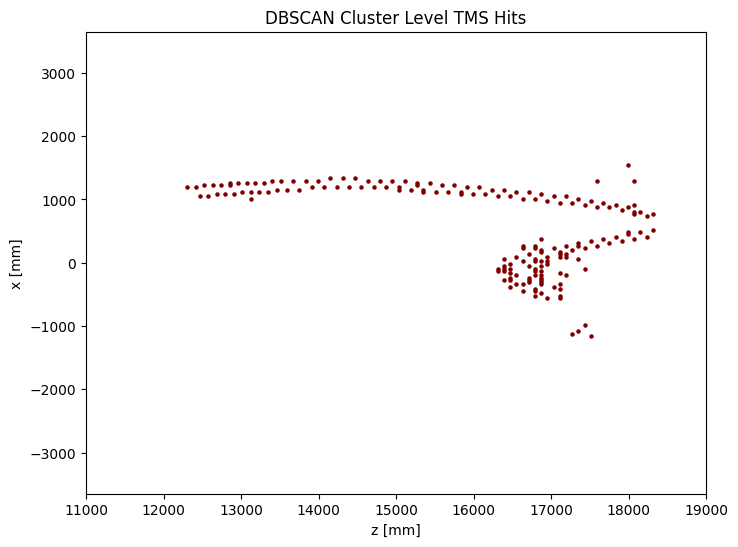

In [5]:
chosen_slice = dbscan_cluster_list[85]

zs = chosen_slice[:,4]
xs = chosen_slice[:,2]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, color='maroon', s =5)
plt.xlabel('z [mm]')
plt.ylim((-3650,3650))
plt.xlim((11000,19000))
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
plt.ylabel('x [mm]')
plt.title('DBSCAN Cluster Level TMS Hits')
plt.savefig('dbscan_level.png')
print(xmin,xmax)
print(ymin,ymax)

In [31]:
graph_numbers = []
for data in torch_dataset:
    graph_numbers.append(data.graph_number)
graph_numbers.index(85)

80

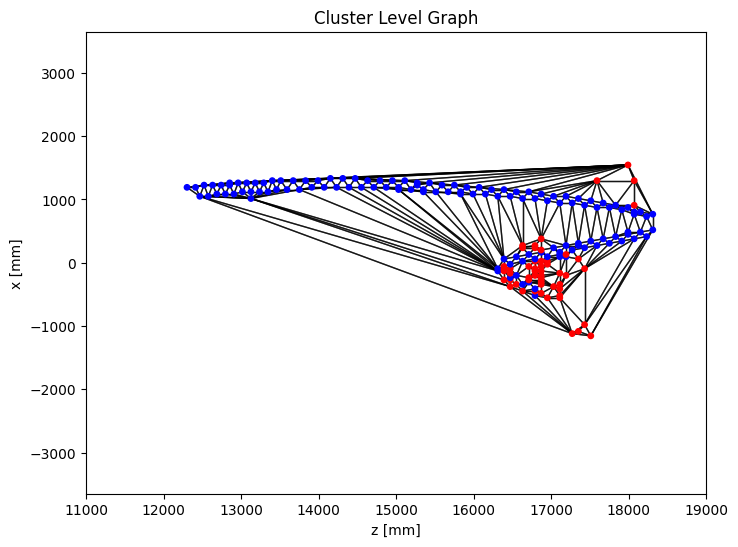

In [40]:
cluster_n = 80
zs = (torch_dataset[cluster_n].x)[:,0]
xs = (torch_dataset[cluster_n].x)[:,1]
nodes = (torch_dataset[cluster_n].x)[:,[0,1]]
labels = (torch_dataset[cluster_n].y)

colors = []
for label in labels:
    if label == 0:
        colors.append('blue')
    else:
        colors.append('red')
        
edges_z = zs[torch_dataset[cluster_n].edge_index]
edges_x = xs[torch_dataset[cluster_n].edge_index]
plt.figure(figsize=(8, 6))
plt.plot(edges_z.numpy(), edges_x.numpy(), 'k-', lw=1, alpha=0.7)
plt.xlim((xmin,xmax))
plt.ylim((ymin,ymax))
plt.scatter(zs, xs, c= colors , s= 15, zorder=3)
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Cluster Level Graph')
plt.savefig('labeled_graph.png')

In [6]:
np.unique(chosen_slice[:,0])

array([210., 221., 224.])

In [7]:
spill_0 = spill_level_hits[0]

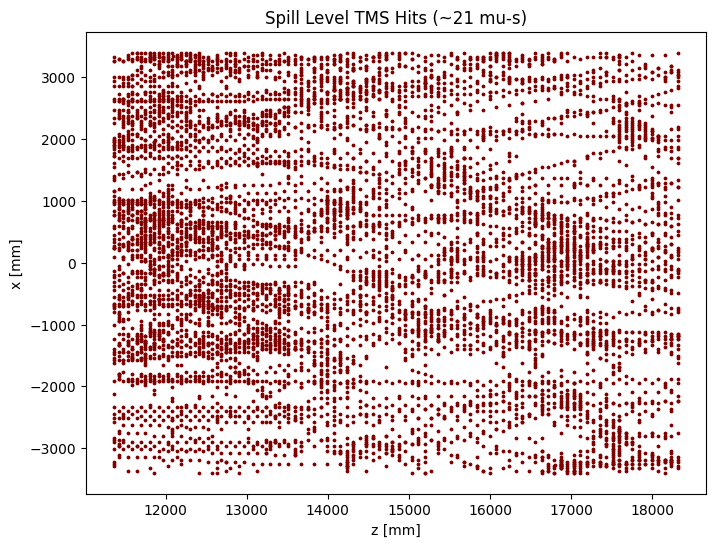

In [8]:
zs = spill_0[:,4]
xs = spill_0[:,2]
nns = spill_0[:,0]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s = 3, c = 'maroon')#c = nns, cmap = 'nipy_spectral' )
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Spill Level TMS Hits (~21 mu-s)')
plt.savefig('presentation_plots/maroon_spill_level.png')

In [9]:
time_segement_hits = spill_0[spill_0[:,-2] == 37]
max(time_segement_hits[:,5]) - min(time_segement_hits[:,5])

np.float64(256.04511555006593)

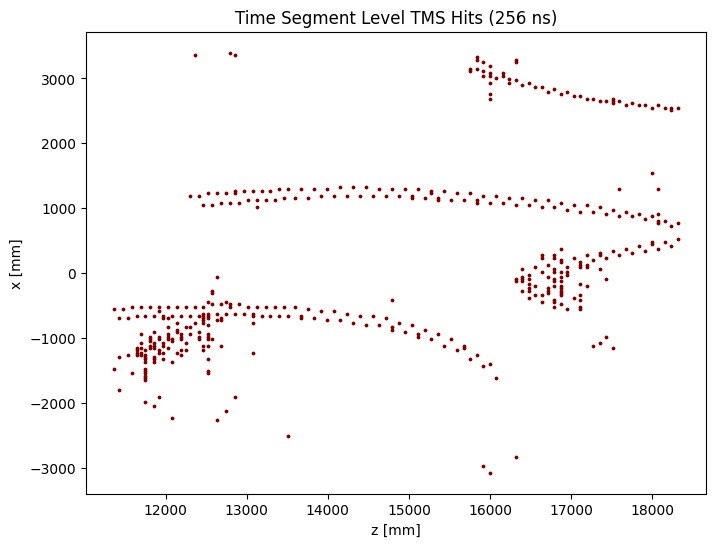

In [10]:
zs = time_segement_hits[:,4]
xs = time_segement_hits[:,2]
plt.figure(figsize=(8, 6))
plt.scatter(zs, xs, s = 3, c = 'maroon' )
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.title('Time Segment Level TMS Hits (256 ns)')
plt.savefig('presentation_plots/segment_level.png')

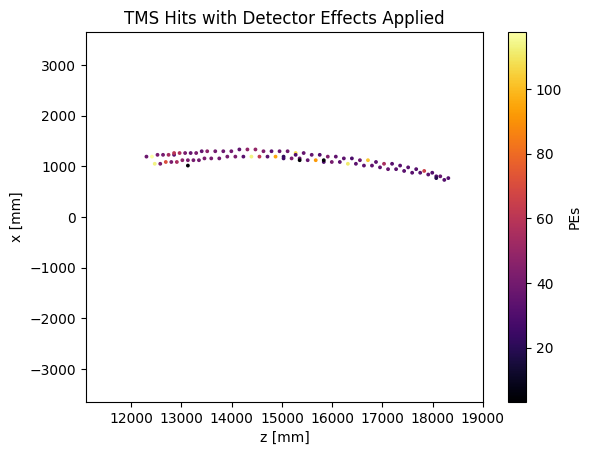

In [11]:
effects_hits = merged_hits_array[merged_hits_array[:,0] == 224]
zs = effects_hits[:,4]
xs = effects_hits[:,2]
PEs = effects_hits[:,6]
plt.scatter(zs, xs, s =3, c = PEs, cmap = 'inferno')
plt.title('TMS Hits with Detector Effects Applied')
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.colorbar(label = 'PEs')
plt.xlim((11100,19000))
plt.ylim((-3650,3650))
plt.savefig('presentation_plots/detector_effects.png')

In [12]:
#hes back
class TMS_hit_simple:
    def __init__(self, tms_hit_seg, neutrino_number, hit_number):
        self.tms_hit_seg = tms_hit_seg
        self.neutrino_number = neutrino_number #associated with what neutrino vertex
        self.hit_number = hit_number #which TMS hit in the event
        self.x_diff = 0.
        self.y_diff = 0.
        self.z_diff = 0.
        self.Dx = 0.
        
    #Defining attributes based on the tms_hit_seg, avg position in each dimension plus time and energy deposition
    def GetNeutrinoNumber(self):
        return(self.neutrino_number)
        
    def GetHitNumber(self):
        return(self.hit_number)
        
    def GetHitX(self):
        x_pos = (self.tms_hit_seg.GetStart()[0] + self.tms_hit_seg.GetStop()[0]) / 2 
        return(x_pos)
        
    def GetHitY(self):
        y_pos = (self.tms_hit_seg.GetStart()[1] + self.tms_hit_seg.GetStop()[1]) / 2
        return(y_pos)
        
    def GetHitZ(self):
        z_pos = (self.tms_hit_seg.GetStart()[2] + self.tms_hit_seg.GetStop()[2]) / 2
        return(z_pos)
        
    def GetHitT(self):
        time = (self.tms_hit_seg.GetStart()[3] + self.tms_hit_seg.GetStop()[3]) / 2
        return(time)
        
    def GetDx(self):
        self.x_diff = (self.tms_hit_seg.GetStart()[0] - self.tms_hit_seg.GetStop()[0])
        self.y_diff = (self.tms_hit_seg.GetStart()[1] - self.tms_hit_seg.GetStop()[1])
        self.z_diff = (self.tms_hit_seg.GetStart()[2] - self.tms_hit_seg.GetStop()[2])
        self.Dx = ((self.x_diff)**2 + (self.y_diff)**2 + (self.z_diff)**2)**(1/2)
        return(self.Dx)
        
    def GetPrimaryDeposit(self):
        PrimaryDeposit = self.tms_hit_seg.GetEnergyDeposit()
        return(PrimaryDeposit)    

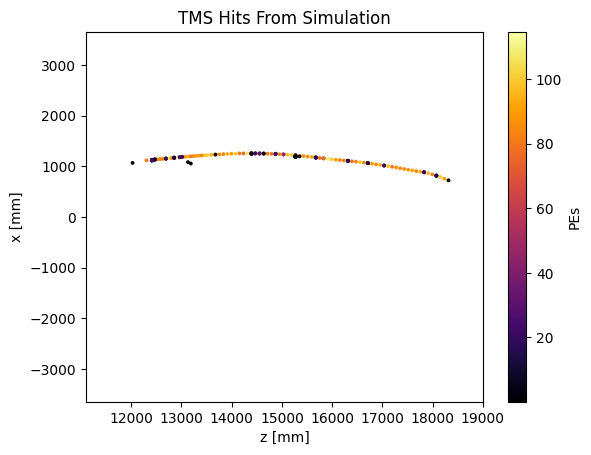

In [13]:
edep_evts = f.Get("EDepSimEvents") 
edep_evt = root.TG4Event()
edep_evts.SetBranchAddress("Event",root.AddressOf(edep_evt))
edep_evts.GetEntry(224)
hit_segments = edep_evt.SegmentDetectors['volTMS']
xs = []
zs = []
PEs = []
for i in range(hit_segments.size()):
    hit_true = TMS_hit_simple(hit_segments[i], 224, i)
    xs.append(hit_true.GetHitX())
    zs.append(hit_true.GetHitZ())
    PEs.append(hit_true.GetPrimaryDeposit()*50)

plt.scatter(zs, xs, s =3, c = PEs, cmap = 'inferno')
plt.title('TMS Hits From Simulation')
plt.xlabel('z [mm]')
plt.ylabel('x [mm]')
plt.colorbar(label = 'PEs')
plt.xlim((11100,19000))
plt.ylim((-3650,3650))
plt.savefig('presentation_plots/raw_sim.png')

In [14]:
#We did a run on a larger chunk of files lets see how it went. 
dbscan_clustered_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/dbscan_clustered' 
dbscan_clustered_paths = glob.glob(os.path.join(dbscan_clustered_directory, "*.npz")) 
print(len(dbscan_clustered_paths))

102


In [15]:
big_pe_eff = []
big_hit_eff = []
big_occupancy = [] 
spill_accuracy = []
index = 0
spill_number = []
for file_path in dbscan_clustered_paths:
    with np.load(file_path) as file:
        #quickly check the spill stuff
        if 1 == 1:
            #print(file_path)
            #print(max(file['third']))
            n_spills = len(np.unique(file['first'][:,-4]))
            spill_number.append(n_spills)
            big_pe_eff.append(file['second'][:,2])
            big_hit_eff.append(file['second'][:,1])
            big_occupancy.append(file['third'])
        
big_pe_array = np.hstack(big_pe_eff)
big_hit_array = np.hstack(big_hit_eff)
big_occupancy_array = np.hstack(big_occupancy)
len(big_occupancy_array)

312639

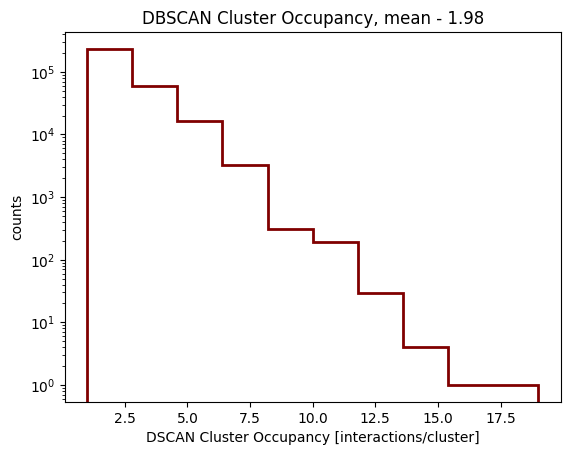

In [16]:
plt.hist(big_occupancy_array, histtype='step', linewidth = 2, edgecolor = 'maroon')
plt.ylabel('counts')
plt.yscale('log')
plt.title(f'DBSCAN Cluster Occupancy, mean - {np.mean(big_occupancy_array):.2f}')
plt.xlabel('DSCAN Cluster Occupancy [interactions/cluster]')
plt.savefig('presentation_plots/dbscan_occ.png')

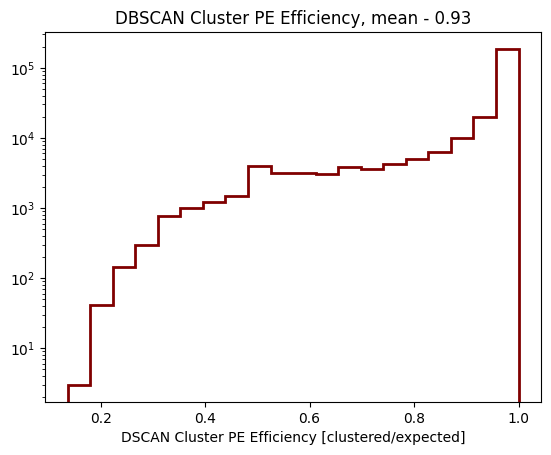

In [17]:
plt.hist(big_pe_array, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.yscale('log')
plt.title(f'DBSCAN Cluster PE Efficiency, mean - {np.mean(big_pe_array):.2f}')
plt.xlabel('DSCAN Cluster PE Efficiency [clustered/expected]')
plt.savefig('presentation_plots/dbscan_pe_eff.png')

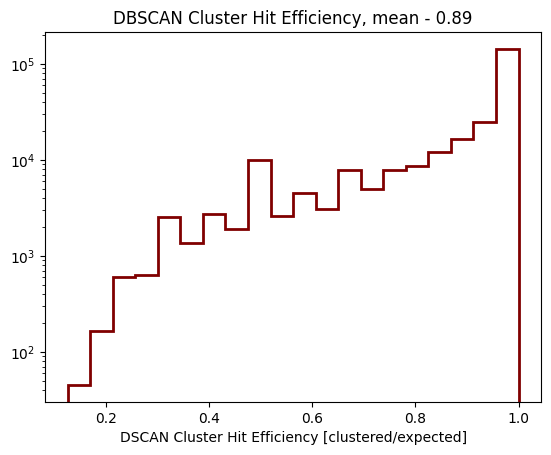

In [18]:
plt.hist(big_hit_array, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.yscale('log')
plt.title(f'DBSCAN Cluster Hit Efficiency, mean - {np.mean(big_hit_array):.2f}')
plt.xlabel('DSCAN Cluster Hit Efficiency [clustered/expected]')
plt.savefig('presentation_plots/dbscan_hit_eff.png')

In [19]:
#How many neutrino interactions are leaving activity in the TMS per spill?? Plus other full run stats!
ints_spill_stats = []
spill_hits_timing = []
time_seg_duration = []
time_seg_occ = []
for file_path in dbscan_clustered_paths:
    with np.load(file_path) as file:
        hits = file['first']
        for spill_number in np.unique(hits[:,-4]):
            spill_hits = hits[hits[:,-4] == spill_number]
            ints_spill_stats.append(len(np.unique(spill_hits[:,0])))
            duration = max(spill_hits[:,5]) - min(spill_hits[:,5])
            spill_hits_timing.append(duration)
            time_segs = np.unique(spill_hits[:,-2])
            for seg_number in time_segs:
                seg_hits = spill_hits[spill_hits[:,-2] == seg_number]
                seg_duration = max(seg_hits[:,5]) - min(seg_hits[:,5])
                time_seg_occ.append(len(np.unique(seg_hits[:,0])))
                if len(seg_hits) > 3:
                    time_seg_duration.append(seg_duration)

1303

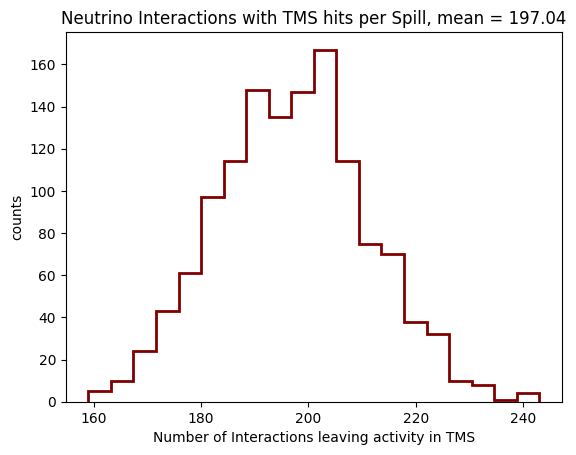

In [20]:
plt.hist(ints_spill_stats, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.ylabel('counts')
plt.xlabel('Number of Interactions leaving activity in TMS')
plt.title(f'Neutrino Interactions with TMS hits per Spill, mean = {np.mean(ints_spill_stats):.2f}')
plt.savefig('presentation_plots/neutrinos_per_spill.png')
len(ints_spill_stats)

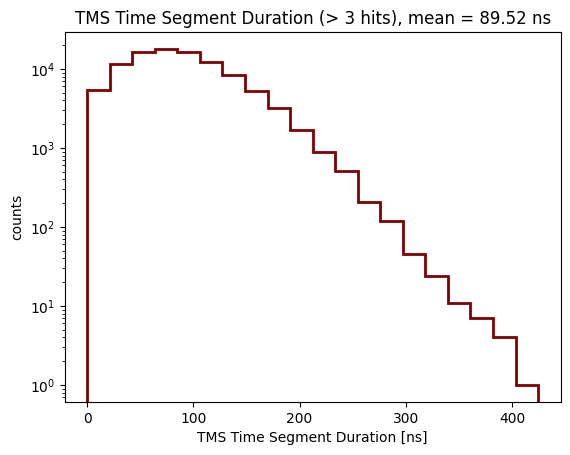

In [21]:
plt.hist(time_seg_duration, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.ylabel('counts')
plt.xlabel('TMS Time Segment Duration [ns]')
plt.title(f'TMS Time Segment Duration (> 3 hits), mean = {np.mean(time_seg_duration):.2f} ns')
plt.yscale('log')
plt.savefig('presentation_plots/segment_duration.png')

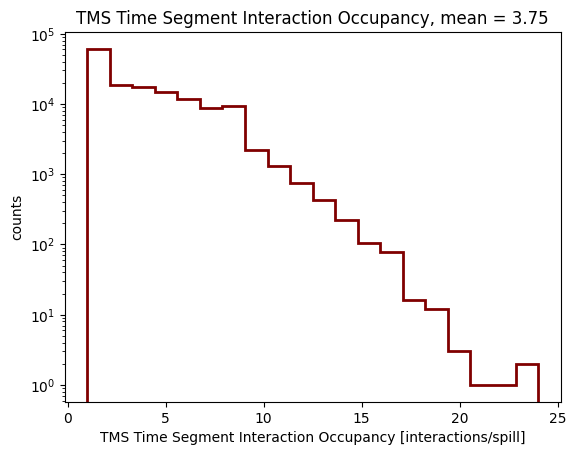

In [22]:
plt.hist(time_seg_occ, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.ylabel('counts')
plt.xlabel('TMS Time Segment Interaction Occupancy [interactions/spill]')
plt.title(f'TMS Time Segment Interaction Occupancy, mean = {np.mean(time_seg_occ):.2f}')
plt.yscale('log')
plt.savefig('presentation_plots/segment_occ.png')


In [23]:
#We did a run on a larger chunk of files lets see how it went. 
big_pe_eff_seg = []
big_hit_eff_seg = []
big_occupancy_seg = []
time_clustered_directory = '/sdf/data/neutrino/summer25/ktwall/tms_timing/time_clustered/truth_spills/' 
time_clustered_paths = glob.glob(os.path.join(time_clustered_directory, "*.npz")) 
for file_path in time_clustered_paths:
    with np.load(file_path) as file:
        big_pe_eff_seg.append(file['second'][:,2])
        big_hit_eff_seg.append(file['second'][:,1])
        big_occupancy_seg.append(file['third'])
big_pe_array_seg = np.hstack(big_pe_eff_seg)
big_hit_array_seg = np.hstack(big_hit_eff_seg)
big_occupancy_array_seg = np.hstack(big_occupancy_seg)

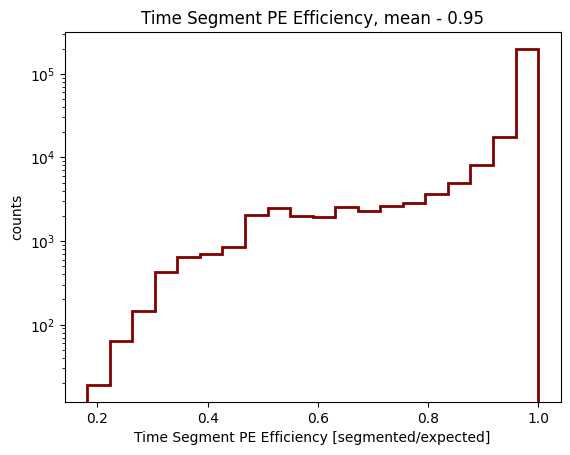

In [24]:
plt.hist(big_pe_array_seg, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.yscale('log')
plt.title(f'Time Segment PE Efficiency, mean - {np.mean(big_pe_array_seg):.2f}')
plt.xlabel('Time Segment PE Efficiency [segmented/expected]')
plt.ylabel('counts')
plt.savefig('presentation_plots/segment_pe_eff.png')

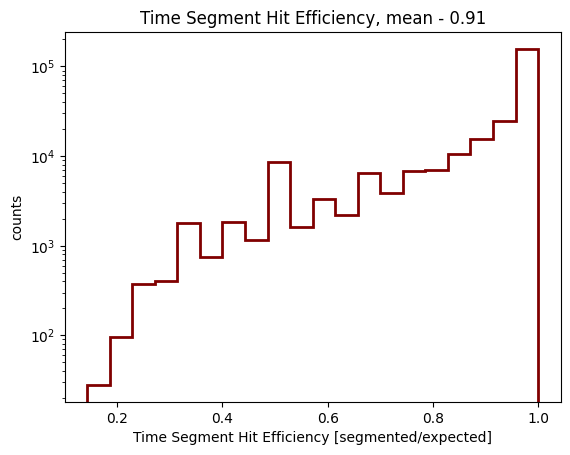

In [25]:
plt.hist(big_hit_array_seg, histtype='step', linewidth = 2, edgecolor = 'maroon', bins = 20)
plt.yscale('log')
plt.title(f'Time Segment Hit Efficiency, mean - {np.mean(big_hit_array_seg):.2f}')
plt.xlabel('Time Segment Hit Efficiency [segmented/expected]')
plt.ylabel('counts')
plt.savefig('presentation_plots/segment_hit_eff.png')